# 高斯核心函式 Gaussian Kernel：公式與 Python 計算範例

這份 Notebook 示範高斯核心函式的基本概念、數學公式，以及如何用 Python 進行計算。

高斯核心函式常見於 SVM、kernel methods、相似度計算與非線性模型中。核心概念是：

> 兩個向量距離越近，相似度越高；距離越遠，相似度越低。


## 1. 數學公式

高斯核心函式的常見形式是：

$$
K(x,z)=\exp\left(-\gamma \lVert x-z \rVert_2^2\right)
$$

其中：

| 符號 | 意義 |
|---|---|
| $x$ | 第一個向量 |
| $z$ | 第二個向量 |
| $K(x,z)$ | 兩個向量的相似度 |
| $\lVert x-z \rVert_2$ | L2 距離，也就是歐氏距離 |
| $\lVert x-z \rVert_2^2$ | L2 距離的平方 |
| $\gamma$ | 控制距離影響程度的參數 |
| $\exp()$ | 指數函數，底數為自然常數 $e$ |

注意：標準高斯核心使用的是 **L2 距離的平方**，不是單純的 L2 距離。


## 2. 範例資料

假設有兩個二維向量：

$$
x=[1,2]
$$

$$
z=[3,4]
$$

先用手算方式理解，再用 Python 驗證。


In [1]:
import numpy as np

x = np.array([1, 2])
z = np.array([3, 4])

x, z

(array([1, 2]), array([3, 4]))

## 3. 計算差向量

$$
x-z=[1-3,2-4]=[-2,-2]
$$


In [2]:
diff = x - z
diff

array([-2, -2])

## 4. 計算 L2 距離

L2 距離公式：

$$
\lVert x-z \rVert_2
=
\sqrt{(x_1-z_1)^2+(x_2-z_2)^2}
$$

代入本例：

$$
\lVert x-z \rVert_2
=
\sqrt{(-2)^2+(-2)^2}
=
\sqrt{8}
\approx 2.828
$$


In [3]:
l2_distance = np.linalg.norm(x - z)
l2_distance

np.float64(2.8284271247461903)

## 5. 計算 L2 距離的平方

高斯核心使用的是：

$$
\lVert x-z \rVert_2^2
$$

本例中：

$$
\lVert x-z \rVert_2^2
=
(-2)^2+(-2)^2
=
8
$$


In [4]:
squared_l2_distance = np.sum((x - z) ** 2)
squared_l2_distance

np.int64(8)

也可以由 L2 距離平方得到相同結果：

$$
\left(\lVert x-z \rVert_2\right)^2 = 8
$$


In [5]:
l2_distance**2

np.float64(8.000000000000002)

## 6. 代入高斯核心函式

假設：

$$
\gamma=0.5
$$

則：

$$
K(x,z)=\exp(-0.5 \times 8)
$$

$$
K(x,z)=\exp(-4)
$$

$$
K(x,z)\approx 0.0183
$$


In [6]:
gamma = 0.5

kernel_value = np.exp(-gamma * squared_l2_distance)
kernel_value

np.float64(0.01831563888873418)

## 7. 寫成一個 Python 函式

為了重複使用，可以把高斯核心寫成函式。


In [7]:
def gaussian_kernel(x, z, gamma):
    """Compute Gaussian / RBF kernel between two vectors.

    Parameters
    ----------
    x : array-like
        First vector.
    z : array-like
        Second vector.
    gamma : float
        Kernel width parameter. Larger gamma means faster similarity decay.

    Returns
    -------
    float
        Kernel similarity between x and z.
    """
    x = np.asarray(x)
    z = np.asarray(z)

    squared_distance = np.sum((x - z) ** 2)
    return np.exp(-gamma * squared_distance)


gaussian_kernel(x, z, gamma=0.5)

np.float64(0.01831563888873418)

## 8. 比較不同 gamma 的結果

同樣的兩個向量，平方 L2 距離固定是：

$$
\lVert x-z \rVert_2^2=8
$$

但不同的 $\gamma$ 會造成不同的相似度。


In [8]:
gammas = [0.1, 0.5, 1.0]

for g in gammas:
    value = gaussian_kernel(x, z, gamma=g)
    print(f"gamma = {g:<3} -> K(x, z) = {value:.6f}")

gamma = 0.1 -> K(x, z) = 0.449329
gamma = 0.5 -> K(x, z) = 0.018316
gamma = 1.0 -> K(x, z) = 0.000335


結果可以解讀為：

| gamma | 效果 |
|---:|---|
| 較小 | 距離影響較弱，相似度下降較慢 |
| 較大 | 距離影響較強，相似度下降較快 |

因此，$\gamma$ 越大，模型越重視局部鄰近點；$\gamma$ 越小，模型越平滑。


## 9. 用表格整理 gamma 與相似度

下面用 pandas 建立表格，方便觀察結果。


In [9]:
import pandas as pd

gamma_values = [0.01, 0.1, 0.5, 1, 2, 5]

results = []
for g in gamma_values:
    results.append(
        {
            "gamma": g,
            "squared_l2_distance": squared_l2_distance,
            "kernel_value": gaussian_kernel(x, z, gamma=g),
        }
    )

df = pd.DataFrame(results)
df

,gamma,squared_l2_distance,kernel_value
0,0.01,8,9.231163e-01
1,0.10,8,4.493290e-01
2,0.50,8,1.831564e-02
3,1.00,8,3.354626e-04
4,2.00,8,1.125352e-07
5,5.00,8,4.248354e-18


## 10. 繪製 gamma 與相似度的關係

下面固定兩個向量的距離，只改變 $\gamma$，觀察高斯核心值如何變化。


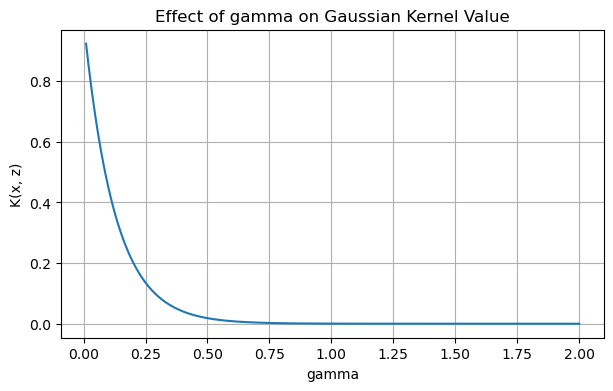

In [10]:
import matplotlib.pyplot as plt

gamma_range = np.linspace(0.01, 2, 200)
kernel_values = [gaussian_kernel(x, z, gamma=g) for g in gamma_range]

plt.figure(figsize=(7, 4))
plt.plot(gamma_range, kernel_values)
plt.xlabel("gamma")
plt.ylabel("K(x, z)")
plt.title("Effect of gamma on Gaussian Kernel Value")
plt.grid(True)
plt.show()

## 11. 與 sigma 形式的關係

高斯核心也常寫成：

$$
K(x,z)=\exp\left(-\frac{\lVert x-z\rVert_2^2}{2\sigma^2}\right)
$$

兩種寫法的關係是：

$$
\gamma=\frac{1}{2\sigma^2}
$$

因此：

- $\sigma$ 越大，影響範圍越廣
- $\sigma$ 越小，影響範圍越窄
- $\gamma$ 和 $\sigma$ 是反向關係


In [ ]:
def gamma_from_sigma(sigma):
    return 1 / (2 * sigma**2)


sigma_values = [0.5, 1, 2, 5]

sigma_df = pd.DataFrame(
    {"sigma": sigma_values, "gamma": [gamma_from_sigma(s) for s in sigma_values]}
)

sigma_df

,sigma,gamma
0,0.5,2.000
1,1.0,0.500
2,2.0,0.125
3,5.0,0.020


## 12. 實務設定 gamma 的簡單原則

在實務上，$\gamma$ 通常被視為 **超參數 hyperparameter**，需要透過資料與模型表現來選擇。

常見原則：

1. **先標準化特徵**  
   因為高斯核心依賴距離，如果特徵尺度不同，距離會被大尺度特徵主導。

2. **用特徵數作為初始參考**  
   若資料已標準化，可先嘗試：

   $$
   \gamma \approx \frac{1}{n_{\text{features}}}
   $$

3. **用 cross-validation 搜尋**  
   常用對數尺度搜尋：

   $$
   \gamma \in \{10^{-3},10^{-2},10^{-1},1,10,100\}
   $$

4. **判斷 overfitting 與 underfitting**  
   - 若模型 overfitting，可嘗試降低 $\gamma$
   - 若模型 underfitting，可嘗試提高 $\gamma$


## 13. 簡短總結

高斯核心函式：

$$
K(x,z)=\exp\left(-\gamma \lVert x-z \rVert_2^2\right)
$$

重點如下：

- 它衡量兩個向量的相似度。
- 相似度範圍通常介於 0 到 1。
- 距離越近，相似度越接近 1。
- 距離越遠，相似度越接近 0。
- 標準高斯核心使用的是 L2 距離的平方。
- $\gamma$ 越大，相似度下降越快。
- $\gamma$ 越小，相似度下降越慢。
